# Day 3 — EDA Part 1: Distributions
### Real Estate Machine · Graduation Project

**Goal today:** understand the *shape* of every variable, one at a time, before asking how they
relate to each other (that is Day 4).

A distribution answers three questions about a column:

1. Where does the mass sit? (centre)
2. How spread out is it? (spread)
3. Is it symmetric, or does it have a long tail? (skew)

Question 3 is the one that decides how we model. Everything else today follows from it.

---

### What you should be able to answer at the end of today

1. Why is `price` right-skewed, and what does that do to a linear model?
2. What exactly does the log transform fix — and what does it *not* fix?
3. Which categories in this dataset are too rare to trust?
4. Which cities are expensive, and which are just *big*?

> **Defense question you are preparing for:** *"Why did you model log(price) instead of price?"*

## 1. Setup

We start from `data_clean.csv` — the Day 2 output, 4,345 rows and 21 columns.
Nothing is cleaned or dropped in this notebook. Today is observation only.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = Path("..") / "Data"
FIGS = Path("..") / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

def save(fig, name):
    """Save a figure into reports/figures so it can go straight into the slides."""
    path = FIGS / f"{name}.png"
    fig.savefig(path)
    print("saved ->", path)

df = pd.read_csv(DATA / "data_clean.csv", parse_dates=["date"])
print("Shape:", df.shape)
df.head(3)

Shape: (4345, 21)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zipcode,was_renovated,effective_year,house_age,age_effective,price_per_sqft
0,2014-05-02,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,NaN,Shoreline,98133,0,1955,59,59,233.58
1,2014-05-02,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,NaN,Seattle,98119,0,1921,93,93,653.15
2,2014-05-02,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,NaN,Kent,98042,0,1966,48,48,177.20


Two reminders carried over from Day 2, because they matter today:

- **`price_per_sqft` is derived from the target.** It is excellent for *understanding* the market
  and useless — in fact harmful — as a model input. Using it today is fine. Using it on Day 6 is
  target leakage.
- **The date range is only ~10 weeks**, so there is no time dimension worth plotting.

In [ ]:
NUMERIC = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
           "sqft_above", "sqft_basement", "house_age", "price_per_sqft"]
CATEGORICAL = ["waterfront", "view", "condition", "floors", "was_renovated"]

df[NUMERIC].describe().T[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
price,"4,345.00","555,721.12","369,317.50","80,000.00","471,000.00","7,062,500.00"
bedrooms,"4,345.00",3.40,0.91,1.00,3.00,9.00
bathrooms,"4,345.00",2.16,0.78,0.75,2.25,8.00
sqft_living,"4,345.00","2,136.18",958.16,370.00,"1,970.00","13,540.00"
sqft_lot,"4,345.00","14,854.02","36,268.53",638.00,"7,666.00","1,074,218.00"
floors,"4,345.00",1.51,0.54,1.00,1.50,3.50
sqft_above,"4,345.00","1,823.89",854.78,370.00,"1,590.00","9,410.00"
sqft_basement,"4,345.00",312.30,463.75,0.00,0.00,"4,820.00"
house_age,"4,345.00",43.14,29.81,0.00,38.00,114.00
price_per_sqft,"4,345.00",264.64,106.46,87.65,247.66,800.00


---
## 2. The target: `price`

Always plot the target first. Every modelling decision downstream is a reaction to its shape.

saved -> ..\reports\figures\03_price_distribution.png


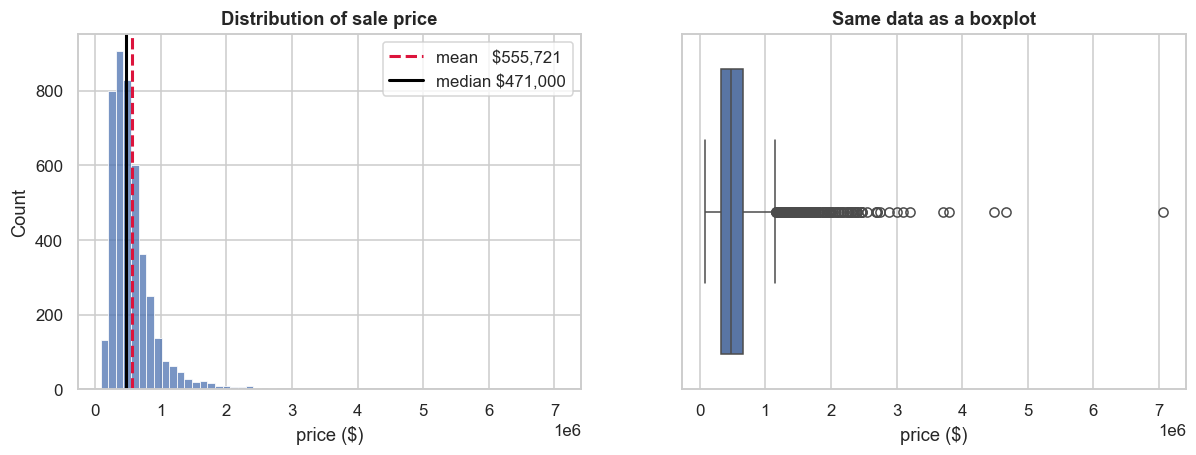

mean   : $     555,721
median : $     471,000
mean / median = 1.18
skewness: 4.02


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(df["price"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].axvline(df["price"].mean(),   color="crimson", ls="--", lw=2, label=f"mean   ${df['price'].mean():,.0f}")
axes[0].axvline(df["price"].median(), color="black",   ls="-",  lw=2, label=f"median ${df['price'].median():,.0f}")
axes[0].set_title("Distribution of sale price")
axes[0].set_xlabel("price ($)")
axes[0].legend()

sns.boxplot(x=df["price"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Same data as a boxplot")
axes[1].set_xlabel("price ($)")

save(fig, "03_price_distribution")
plt.show()

print(f"mean   : ${df['price'].mean():>12,.0f}")
print(f"median : ${df['price'].median():>12,.0f}")
print(f"mean / median = {df['price'].mean() / df['price'].median():.2f}")
print(f"skewness: {stats.skew(df['price']):.2f}")

### Reading it

**The mean sits well above the median.** For a symmetric distribution the two coincide. Here the
mean is dragged upward by a small number of very expensive houses — the classic signature of a
**right-skewed** (positively skewed) variable.

**Skewness ≈ 4.0.** As a rough rule of thumb: |skew| < 0.5 is near-symmetric, 0.5–1 is moderate,
above 1 is strong. Four is *very* strong.

**The boxplot is misleading and you should say so.** It marks a large number of houses as
"outliers" — but Day 2 already removed the genuinely impossible prices. What remains is real
luxury housing. A boxplot flags anything beyond 1.5×IQR, and that rule assumes a roughly symmetric
distribution. On skewed data it mislabels the entire upper tail. **The tail is the market, not an
error.**

> This is the single most common EDA mistake: deleting everything a boxplot calls an outlier.
> You would be deleting Medina and Mercer Island.

---
## 3. The log transform

The standard remedy for a multiplicative, positive, right-skewed quantity is to model its
logarithm. Let us check that it actually works here rather than assuming it.

saved -> ..\reports\figures\03_price_log_transform.png


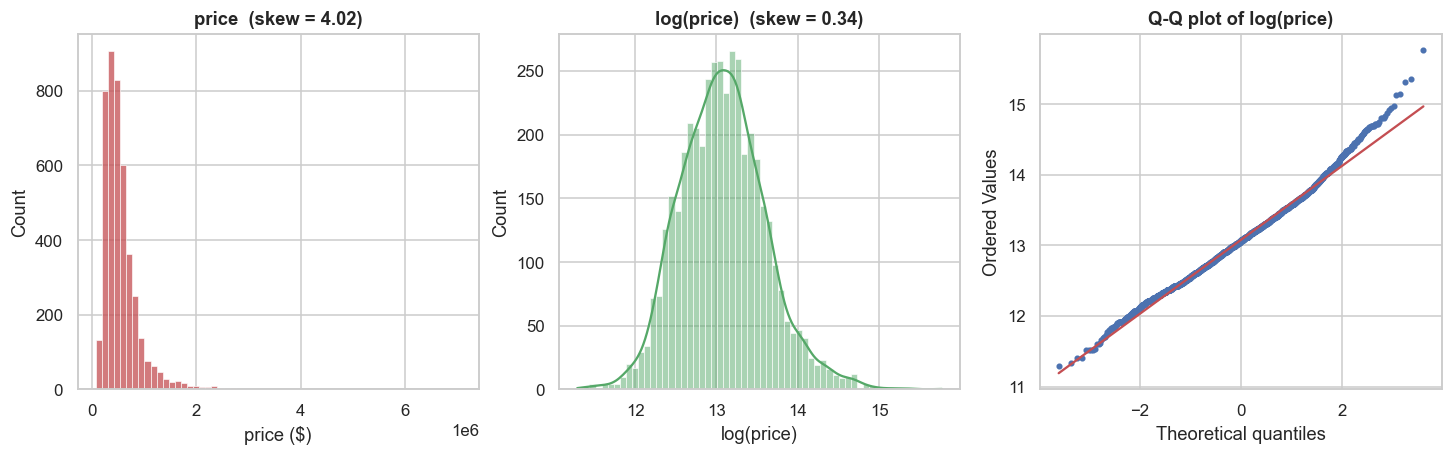

In [ ]:
df["log_price"] = np.log(df["price"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.histplot(df["price"], bins=60, ax=axes[0], color="#C44E52")
axes[0].set_title(f"price  (skew = {stats.skew(df['price']):.2f})")
axes[0].set_xlabel("price ($)")

sns.histplot(df["log_price"], bins=60, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log(price)  (skew = {stats.skew(df['log_price']):.2f})")
axes[1].set_xlabel("log(price)")

stats.probplot(df["log_price"], dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of log(price)")
axes[2].get_lines()[0].set_markersize(3)

save(fig, "03_price_log_transform")
plt.show()

### What just happened

| | skewness |
|---|---|
| `price` | ~4.0 |
| `log(price)` | ~0.3 |

The transform turned a strongly right-skewed variable into a nearly symmetric one. The Q-Q plot
sits on the diagonal through the middle of the range and bends only at the very ends — meaning
log(price) is close to normal except in the extreme tails.

### Why this matters — stated precisely

You will read everywhere that *"linear regression assumes the target is normally distributed."*
**That is wrong, and an examiner may test you on it.** OLS assumes the *residuals* are
homoscedastic (and, for exact inference, normal). It assumes nothing about the marginal
distribution of *y*.

So the honest reasons for using log(price) are these three:

1. **Squared error follows the scale of the data.** RMSE on raw prices is dominated by the few
   houses worth several million; a 10% miss on a $6M home contributes 100× more penalty than a 10%
   miss on a $600k home. The model spends its capacity on the tail and underfits the typical house.
2. **Housing effects are multiplicative, not additive.** A waterfront view adds a *percentage*, not
   a fixed number of dollars. `log(price) = a + b·x` states exactly that; a linear model on raw
   price forces every effect to be a flat dollar amount.
3. **Residual variance grows with price** (expensive houses have wider absolute errors). Taking
   logs stabilises that spread — the actual assumption OLS cares about.

### The catch you must not forget

If you train on `log(price)`, your predictions come out in log units. You have to convert back
with `np.exp()` before reporting any error in dollars — and `exp(mean of logs)` is the *geometric*
mean, which is slightly below the arithmetic mean. Reporting RMSE in log units and calling it
accuracy is a real mistake students make on Day 9. **Write this down now.**

---
## 4. Every numeric feature at once

Before looking at any feature in detail, look at all of them together. Grid plots are for
spotting the odd one out, not for the slides.

saved -> ..\reports\figures\03_numeric_histograms.png


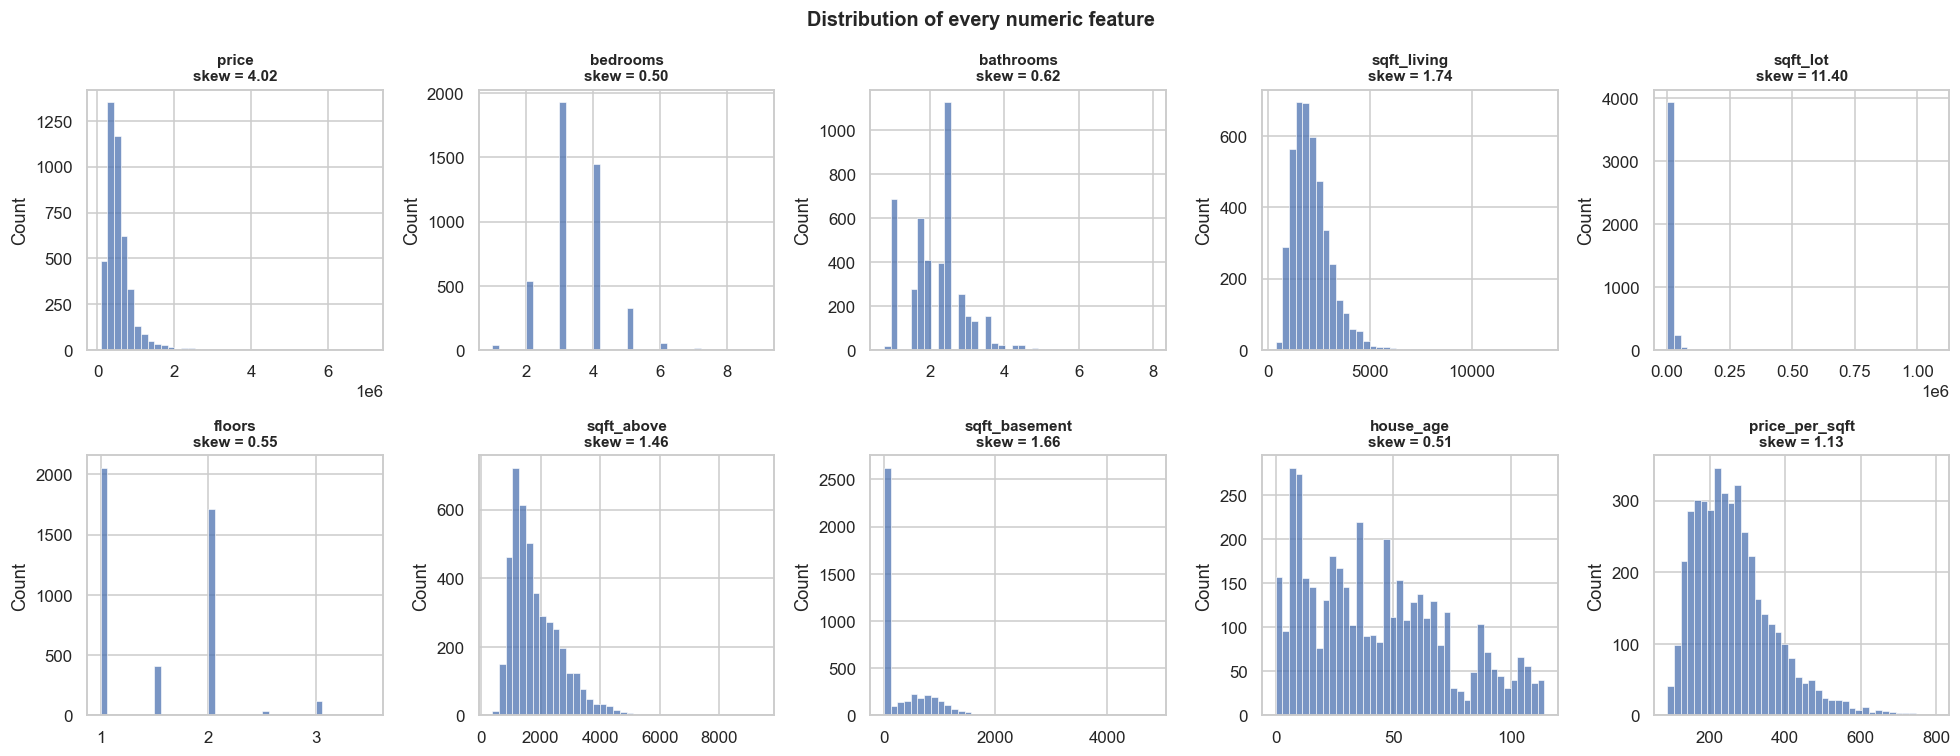

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, col in zip(axes.ravel(), NUMERIC):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}\nskew = {stats.skew(df[col]):.2f}", fontsize=10)
    ax.set_xlabel("")

fig.suptitle("Distribution of every numeric feature", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "03_numeric_histograms")
plt.show()

In [ ]:
skew_table = (
    pd.DataFrame({
        "skewness":     [stats.skew(df[c]) for c in NUMERIC],
        "log1p_skew":   [stats.skew(np.log1p(df[c])) for c in NUMERIC],
        "min":          [df[c].min() for c in NUMERIC],
        "median":       [df[c].median() for c in NUMERIC],
        "max":          [df[c].max() for c in NUMERIC],
    }, index=NUMERIC)
    .sort_values("skewness", ascending=False)
)
skew_table

,skewness,log1p_skew,min,median,max
sqft_lot,11.40,0.84,638.00,"7,666.00","1,074,218.00"
price,4.02,0.34,"80,000.00","471,000.00","7,062,500.00"
sqft_living,1.74,-0.05,370.00,"1,970.00","13,540.00"
sqft_basement,1.66,0.43,0.00,0.00,"4,820.00"
sqft_above,1.46,0.24,370.00,"1,590.00","9,410.00"
price_per_sqft,1.13,0.07,87.65,247.66,800.00
bathrooms,0.62,-0.23,0.75,2.25,8.00
floors,0.55,0.30,1.00,1.50,3.50
house_age,0.51,-1.20,0.00,38.00,114.00
bedrooms,0.50,-0.35,1.00,3.00,9.00


### The one that stands out: `sqft_lot`

Skewness above 11 — nearly three times worse than price. The largest lot is about 140 times the median lot. That is not an error: it is the difference between a Seattle townhouse on a
1,000 sqft plot and a semi-rural property in Carnation on several acres.

`log1p(sqft_lot)` brings the skew down to under 1. We will use the log version as the feature on
Day 6 and keep the raw column for readability.

`sqft_basement` is a special case — its skew comes from the ~60% of houses that have no basement
at all, so the column is really a spike at zero plus a distribution. A log will not fix that;
splitting it into `has_basement` (flag) + size is the right move, which is exactly what Day 6 does.

> **Rule to remember:** skew caused by a *long tail* is fixed by a log. Skew caused by a *pile of
> zeros* is fixed by a flag, not a log.

saved -> ..\reports\figures\03_sqft_lot_log.png


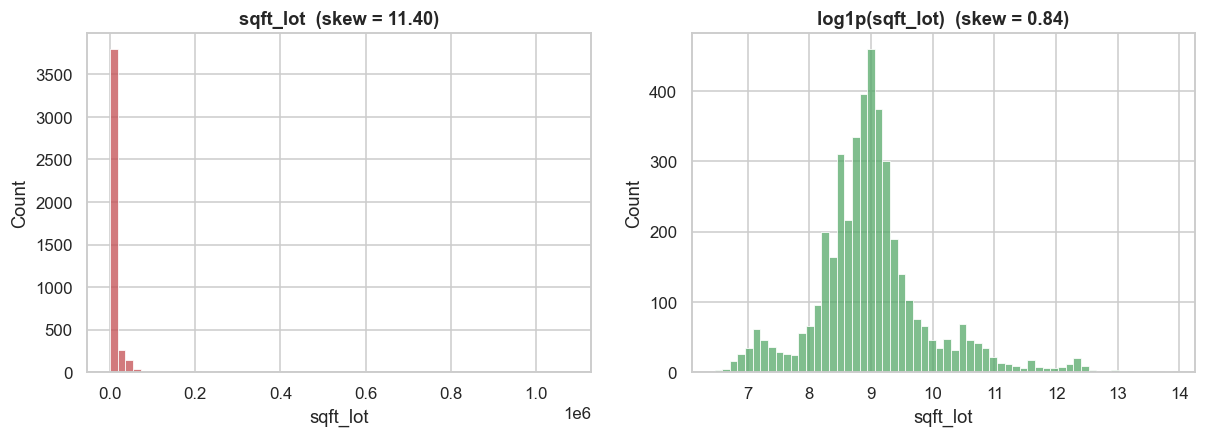

Lot size percentiles (sqft):
count       4,345.00
mean       14,854.00
std        36,269.00
min           638.00
1%          1,019.00
25%         5,000.00
50%         7,666.00
75%        10,920.00
95%        43,560.00
99%       207,938.00
max     1,074,218.00
Name: sqft_lot, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["sqft_lot"], bins=60, ax=axes[0], color="#C44E52")
axes[0].set_title(f"sqft_lot  (skew = {stats.skew(df['sqft_lot']):.2f})")

sns.histplot(np.log1p(df["sqft_lot"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title(f"log1p(sqft_lot)  (skew = {stats.skew(np.log1p(df['sqft_lot'])):.2f})")

save(fig, "03_sqft_lot_log")
plt.show()

print("Lot size percentiles (sqft):")
print(df["sqft_lot"].describe([.01, .25, .5, .75, .95, .99]).round(0))

---
## 5. Boxplots — spread and tails side by side

Histograms show shape; boxplots show quartiles and let you compare several variables at once.
Because the columns are on wildly different scales, we standardise them first — the plot is about
*shape*, not magnitude.

saved -> ..\reports\figures\03_numeric_boxplots.png


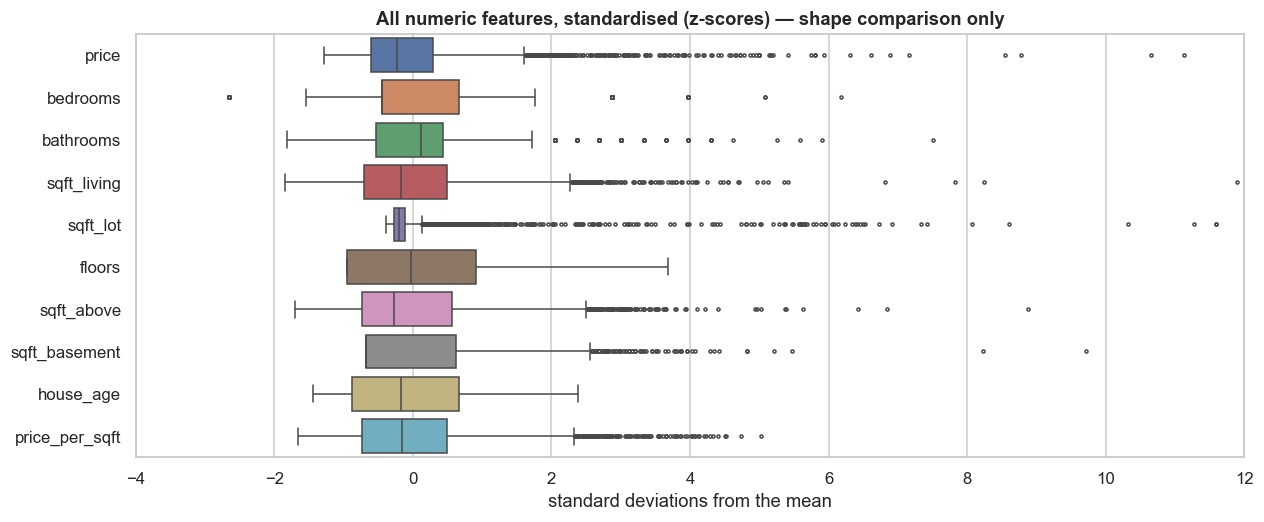

In [ ]:
scaled = (df[NUMERIC] - df[NUMERIC].mean()) / df[NUMERIC].std()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=scaled, orient="h", ax=ax, fliersize=2)
ax.set_title("All numeric features, standardised (z-scores) — shape comparison only")
ax.set_xlabel("standard deviations from the mean")
ax.set_xlim(-4, 12)

save(fig, "03_numeric_boxplots")
plt.show()

Read this plot as *"how far does the right whisker stretch compared to the left one?"*
Every one of these variables is asymmetric to the right. Not a single feature in this dataset is
symmetric — which is normal for property data, where nothing can be negative and the top end is
unbounded.

---
## 6. Price by city

44 cities on one axis is unreadable, so we take the **top 15 by number of sales** and sort them by
median price. Both of those choices are deliberate:

- **Top 15 by count**, because a city with 3 sales gives a median you cannot trust.
- **Sorted by median**, because an alphabetical axis hides the entire story.

saved -> ..\reports\figures\03_price_by_city.png


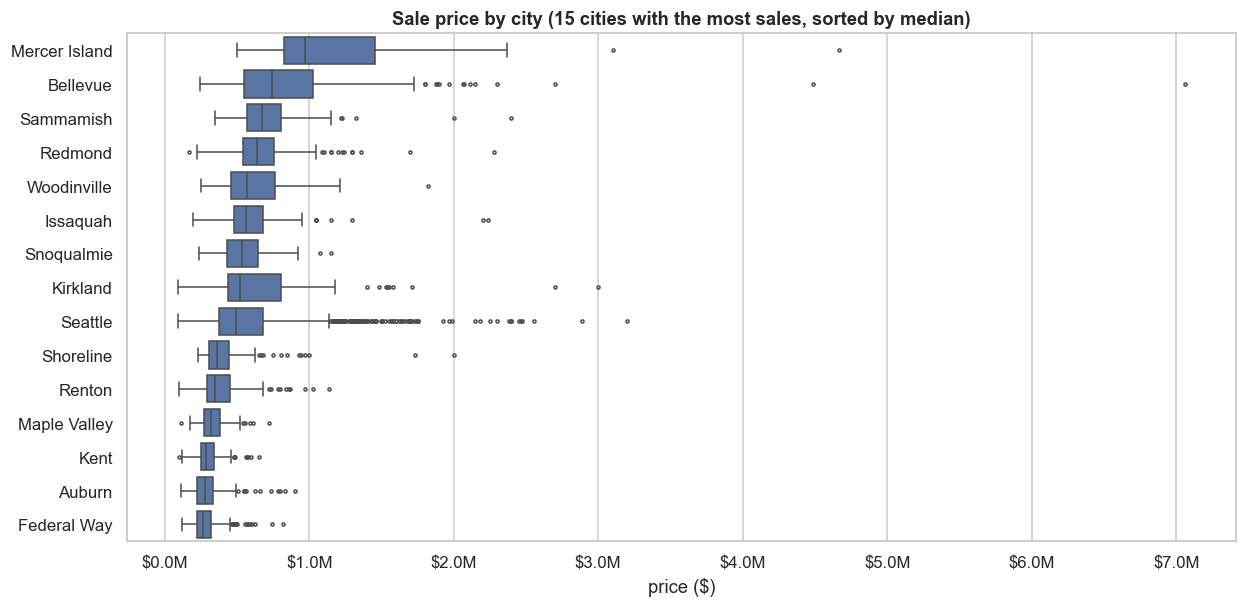

,sales,median_price,median_sqft,median_pps
city,,,,
Mercer Island,75,"970,500.00","3,040.00",359.09
Bellevue,265,"744,500.00","2,450.00",303.00
Sammamish,160,"671,225.00","2,785.00",247.69
Redmond,227,"638,000.00","2,380.00",274.75
Woodinville,109,"570,000.00","2,550.00",232.86
Issaquah,182,"563,000.00","2,245.00",258.48
Snoqualmie,69,"536,751.00","2,500.00",208.48
Kirkland,180,"523,500.00","2,010.00",274.39
Seattle,1493,"496,752.00","1,660.00",314.05


In [ ]:
top15 = df["city"].value_counts().head(15).index
sub = df[df["city"].isin(top15)].copy()

order = sub.groupby("city")["price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=sub, y="city", x="price", order=order, ax=ax, fliersize=2)
ax.set_title("Sale price by city (15 cities with the most sales, sorted by median)")
ax.set_xlabel("price ($)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}M")

save(fig, "03_price_by_city")
plt.show()

city_summary = (
    sub.groupby("city")
       .agg(sales=("price", "size"),
            median_price=("price", "median"),
            median_sqft=("sqft_living", "median"),
            median_pps=("price_per_sqft", "median"))
       .sort_values("median_price", ascending=False)
)
city_summary

### The trap in this chart

Mercer Island and Bellevue top the median-price ranking. But look at the `median_sqft` column:
those houses are also **larger**. Part of what you are seeing is not "this city is expensive" —
it is "this city has bigger houses".

`median_pps` (price per square foot) is the column that separates the two effects, and it already
reorders the table: **Seattle** has a lower median price than Bellevue but a *higher* price per
square foot than Kirkland or Redmond. Seattle sells small, expensive homes; Redmond sells large,
cheaper-per-foot ones.

That distinction is exactly the kind of insight Day 5's business recommendations are graded on.
We develop it properly tomorrow.

---
## 7. Categorical features — and how rare is too rare

Count plots look trivial. Their real purpose is to find categories with so few rows that any
statistic computed on them is noise, and any one-hot column created from them is a liability.

saved -> ..\reports\figures\03_categorical_counts.png


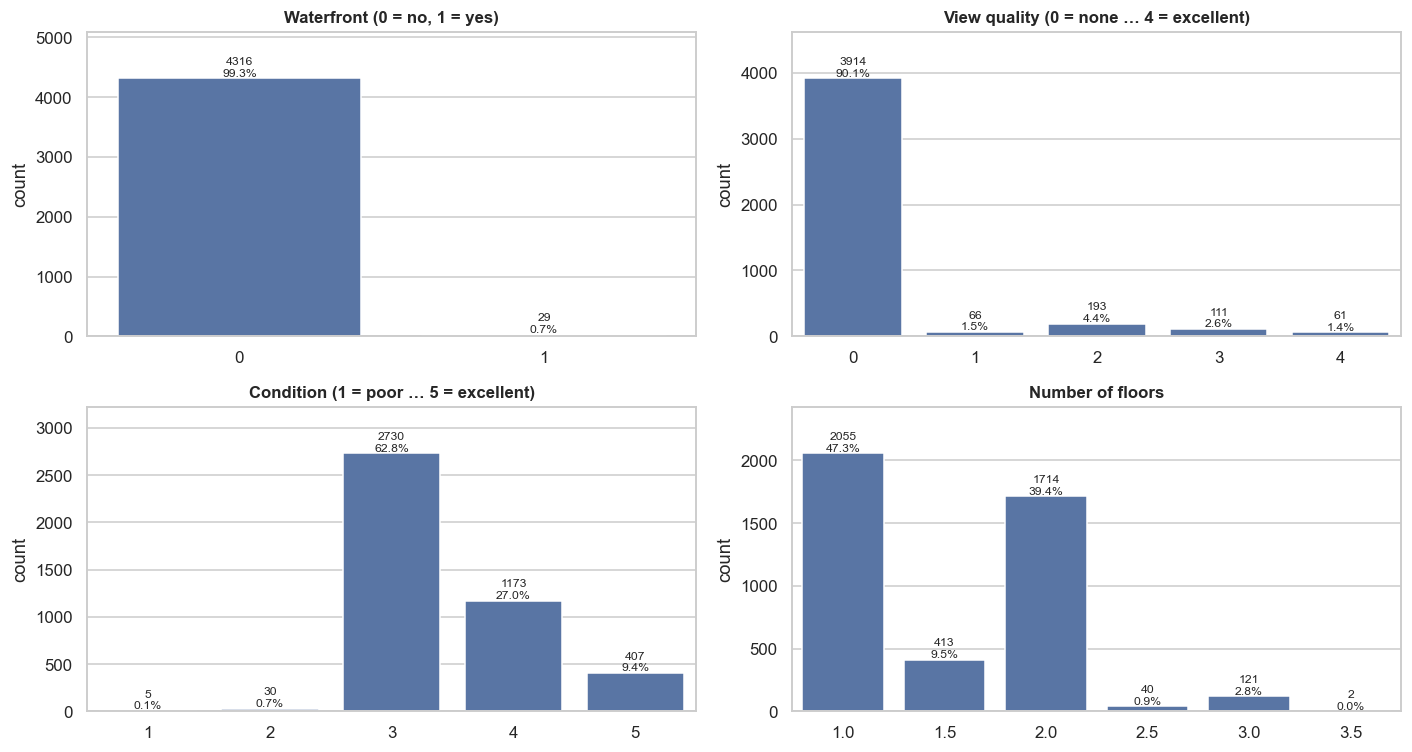

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

specs = [
    ("waterfront", "Waterfront (0 = no, 1 = yes)"),
    ("view",       "View quality (0 = none … 4 = excellent)"),
    ("condition",  "Condition (1 = poor … 5 = excellent)"),
    ("floors",     "Number of floors"),
]

for ax, (col, title) in zip(axes.ravel(), specs):
    sns.countplot(data=df, x=col, ax=ax, color="#4C72B0")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    for p in ax.patches:
        n = int(p.get_height())
        ax.annotate(f"{n}\n{n/len(df)*100:.1f}%",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
    ax.margins(y=0.18)

fig.tight_layout()
save(fig, "03_categorical_counts")
plt.show()

In [ ]:
rows = []
for col in ["waterfront", "view", "condition", "floors", "was_renovated"]:
    vc = df[col].value_counts().sort_index()
    for value, n in vc.items():
        rows.append({"feature": col, "value": value, "n": n, "pct": n / len(df) * 100})

balance = pd.DataFrame(rows)
rare = balance[balance["n"] < 50].copy()
print("Categories with fewer than 50 rows — treat every statistic on these with suspicion:")
rare

Categories with fewer than 50 rows — treat every statistic on these with suspicion:


,feature,value,n,pct
1,waterfront,1.00,29,0.67
7,condition,1.00,5,0.12
8,condition,2.00,30,0.69
15,floors,2.50,40,0.92
17,floors,3.50,2,0.05


### What the counts tell us

| Finding | Number | Consequence |
|---|---|---|
| Only **29 waterfront houses** (0.7%) | 29 | Any "waterfront premium" is a median over 29 homes. Quote it *with* the sample size, always. |
| **90% have `view` = 0** | 3,914 | The four non-zero levels together are ~10% of the data. Consider collapsing to `has_view` on Day 6. |
| **`condition` 1 and 2 are 35 rows combined** | 35 | Effectively an empty category. Collapse into "below average". |
| **`floors` 3.5 has 2 rows** | 2 | A one-hot column with two rows in it is pure noise for the model to memorise. |
| **`condition` = 3 is 63% of the data** | 2,730 | The column is dominated by one value, so it carries much less information than it looks like it does. |

**Why this matters beyond today.** When you split train/test on Day 6, a category with 2 rows may
land entirely in the test set — the model will then meet a value it has never seen. And on Day 8,
`accuracy` on an imbalanced target is a meaningless headline number. That is why the roadmap tells
you to report macro-F1 there.

> **Defense question:** *"Your model says waterfront adds a big premium. How confident are you?"*
> The correct answer names the number 29 before it names the premium.

---
## 8. Where the money actually is: `price_per_sqft`

One last distribution, because it is the variable Day 4 and Day 5 are built on.

saved -> ..\reports\figures\03_price_per_sqft.png


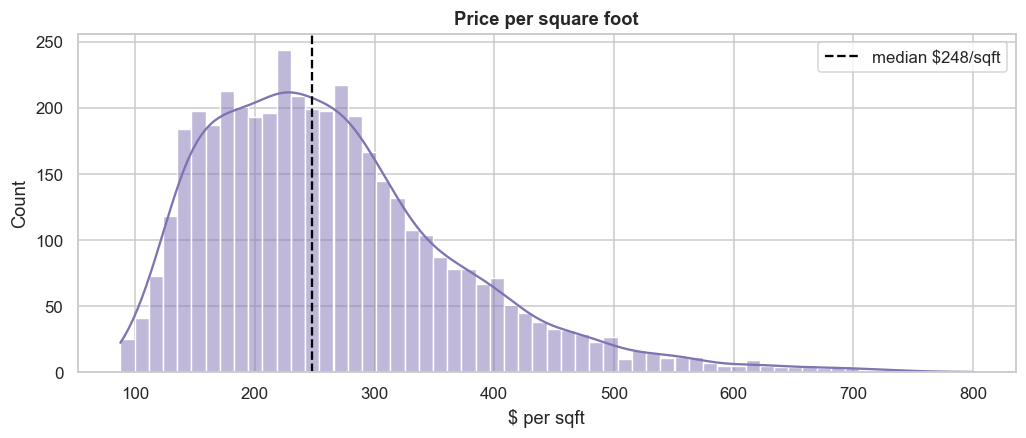

count   4,345.00
mean      264.60
std       106.50
min        87.60
5%        131.70
25%       186.00
50%       247.70
75%       317.10
95%       467.80
max       800.00
Name: price_per_sqft, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(df["price_per_sqft"], bins=60, kde=True, ax=ax, color="#8172B2")
ax.axvline(df["price_per_sqft"].median(), color="black", ls="--",
           label=f"median ${df['price_per_sqft'].median():,.0f}/sqft")
ax.set_title("Price per square foot")
ax.set_xlabel("$ per sqft")
ax.legend()

save(fig, "03_price_per_sqft")
plt.show()

print(df["price_per_sqft"].describe([.05, .25, .5, .75, .95]).round(1))

Far more symmetric than raw price (skew ~1.1 vs ~4.0), because dividing by size removes the
single biggest source of variation. What is left is mostly **location and quality** — which is
precisely why it is the right lens for the business analysis.

**And the leakage warning, one more time:** `price_per_sqft = price / sqft_living`. Feeding it to a
model that predicts `price` hands the model the answer. It stays out of the feature set on Day 6.

---
## 9. What we established today

1. **`price` is strongly right-skewed** (skew ≈ 4.0, mean 18% above median). `log(price)` is
   near-symmetric (skew ≈ 0.3). We will model the log and convert back with `np.exp()` before
   quoting any dollar error.
2. **The boxplot "outliers" in price are real houses**, not errors. Day 2 already removed the
   impossible ones using a neighbourhood-relative rule. We do not delete the luxury tail.
3. **`sqft_lot` is the most skewed feature** (skew > 11) and needs a log; `sqft_basement`'s skew
   comes from a pile of zeros and needs a flag instead.
4. **City median price and city price-per-sqft rank differently.** Some cities are expensive;
   others merely sell bigger houses. Day 4 separates the two.
5. **Several categories are too rare to trust**: 29 waterfront homes, 35 houses in condition 1–2,
   2 houses with 3.5 floors. These get collapsed on Day 6 and caveated in every claim.

### Figures saved to `reports/figures/`

`03_price_distribution` · `03_price_log_transform` · `03_numeric_histograms` ·
`03_sqft_lot_log` · `03_numeric_boxplots` · `03_price_by_city` · `03_categorical_counts` ·
`03_price_per_sqft`

### Before you commit

Rewrite section 9 in your own words. If you cannot explain point 1 to someone who does not know
what skewness is, you do not own it yet.

```powershell
git add . && git commit -m "Day 3: EDA part 1 - distributions"
```

**Next:** Day 4 — how these variables relate to each other, and which ones actually drive price.